In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:\\Users\\Anna\\Downloads\\archive\\moscow_flats_dataset.csv')

## EDA

#### Этот набор данных содержит информацию о нескольких тысячах московских квартир по состоянию на 25 апреля 2024 года.
В нем **12 столбцов**:

- **`price`**: Стоимость объекта недвижимости в рублях.
- **`min_to_metro`**: Примерное время в минутах, необходимое для того, чтобы добраться до ближайшей станции метро от места расположения объекта недвижимости.
- **`region_of_moscow`**: Административный район Москвы, где находится недвижимость. Этот столбец содержит категориальные данные в кириллице. Я укажу значения каждого параметра, а также приведу код для переименования значений на английский язык.
- **`total_area`**: Общая площадь помещения в квадратных метрах.
- **`living_area`**: Жилая площадь объекта недвижимости в квадратных метрах, указывающая на пространство, специально предназначенное для проживания.
- **`floor`**: Номер этажа в здании.
- **`number_of_floors`**: Общее количество этажей в здании, где расположен объект недвижимости.
- **`construction_year`**: Год постройки объекта.
- **`is_new`**: Бинарный индикатор (да/нет или 1/0), указывающий, является ли свойство вновь созданным.
- **`is_apartments`**: Бинарный индикатор (да/нет или 1/0), указывающий, классифицируется ли недвижимость как квартира. Квартиры, в которых можно зарегистрироваться, помечены как 0, а квартиры, в которых это невозможно, — как 1.
- **`ceiling_height`**: Высота потолка в помещении, измеренная в метрах.
- **`number_of_rooms`**: Количество комнат в квартире, включая спальни, гостиные и другие.
- **`link`**: URL-адрес для доступа к более подробной информации об объекте недвижимости в режиме онлайн.

In [3]:

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nТипы данных:\n{df.dtypes}")

display(df.head(10))
display(df.tail(5))


Размер датасета: 6983 строк, 13 столбцов

Типы данных:
price                float64
min_to_metro         float64
region_of_moscow      object
total_area           float64
living_area          float64
floor                float64
number_of_floors     float64
construction_year    float64
is_new               float64
is_apartments        float64
ceiling_height       float64
number_of_rooms      float64
link                  object
dtype: object


,price,min_to_metro,region_of_moscow,total_area,living_area,floor,number_of_floors,construction_year,is_new,is_apartments,ceiling_height,number_of_rooms,link
0,31633073.0,24.0,ЮАО,64.20,32.4,11.0,16.0,2023.0,1.0,0.0,3.15,2.0,https://www.cian.ru/sale/flat/293204033/
1,29293000.0,9.0,СВАО,78.10,NaN,9.0,27.0,2022.0,1.0,0.0,NaN,2.0,https://www.cian.ru/sale/flat/294033524/
2,30349669.0,5.0,ЮАО,72.40,33.6,3.0,24.0,2023.0,1.0,0.0,3.15,2.0,https://www.cian.ru/sale/flat/300712697/
3,31845511.0,19.0,ЮАО,69.20,NaN,2.0,12.0,2024.0,1.0,0.0,2.97,2.0,https://www.cian.ru/sale/flat/300228448/
4,38810000.0,27.0,ЗАО,66.90,24.8,9.0,14.0,2023.0,1.0,0.0,3.00,2.0,https://www.cian.ru/sale/flat/299262105/
5,85004500.0,8.0,ЦАО,104.30,NaN,6.0,7.0,2016.0,1.0,1.0,3.25,2.0,https://www.cian.ru/sale/flat/263389572/
6,82644000.0,3.0,ЦАО,85.20,NaN,52.0,66.0,2020.0,1.0,1.0,3.90,2.0,https://www.cian.ru/sale/flat/296913134/
7,34100453.0,20.0,ЮАО,66.00,29.9,8.0,46.0,2023.0,1.0,0.0,3.00,2.0,https://www.cian.ru/sale/flat/299093558/
8,27447668.0,5.0,ЮАО,65.55,34.4,26.0,26.0,2023.0,1.0,0.0,2.87,2.0,https://www.cian.ru/sale/flat/290283240/
9,21230289.0,5.0,ЗАО,59.30,29.3,23.0,23.0,2023.0,1.0,0.0,2.73,2.0,https://www.cian.ru/sale/flat/298525427/


,price,min_to_metro,region_of_moscow,total_area,living_area,floor,number_of_floors,construction_year,is_new,is_apartments,ceiling_height,number_of_rooms,link
6978,29504877.0,6.0,САО,86.1,49.5,3.0,12.0,NaN,0.0,0.0,NaN,4.0,https://www.cian.ru/sale/flat/298617209/
6979,120000000.0,2.0,ЦАО,163.5,96.0,6.0,6.0,1998.0,0.0,0.0,3.0,4.0,https://www.cian.ru/sale/flat/297548153/
6980,165000000.0,7.0,ЦАО,154.0,76.0,16.0,21.0,2023.0,0.0,0.0,NaN,4.0,https://www.cian.ru/sale/flat/295795425/
6981,21500000.0,11.0,ЮВАО,94.2,69.0,2.0,5.0,NaN,0.0,0.0,2.8,4.0,https://www.cian.ru/sale/flat/300870085/
6982,80000000.0,9.0,САО,139.0,86.0,13.0,14.0,2018.0,0.0,1.0,3.0,4.0,https://www.cian.ru/sale/flat/299185566/


## Выдвижение гипотез.

### Гипотеза. Этажность в новостройках vs. Вторичном фонде
> **Формулировка:** В новостройках покупатели меньше дисконтируют первые и последние этажи, чем во вторичном фонде.


## Очистка данных

### Шаг 1. Фильтрация по типу недвижимости
Столбец `is_apartments` содержит данные о категории объекта недвижимости: *квартира* или *апартаменты*. 

Так как для анализа требуются **только квартиры**, перед удалением дубликатов, отфильтруем датасет от строк с апартаментами, чтобы убрать избыточную информацию. 
Пропуски намеренно оставим, к нем вернемся чуть позже.

In [4]:
df['is_apartments'].value_counts(dropna=False)

is_apartments
0.0    5861
1.0    1088
NaN      34
Name: count, dtype: int64

In [5]:
df = df[df['is_apartments'] != 1.0]

In [6]:
print(f"Размер датасета: {df.shape[0]} строк")

Размер датасета: 5895 строк


### Шаг 2. Удаление дубликатов

Признак `link` должен содержать уникальные значения, так как это ссылки на конкретные объявления:
- проверим наличие дубликатов по этому столбцу;
- выведем строки с дублирующимися значениями, чтобы визуально проверить, полностью ли совпадают эти дубликаты;
- при неполном совпадении воспользуемся дополнительным возможностями датасета для уточнения ошибочных данных в дубликатах
- удалим дубликаты, оставив строки с верными значениями.

In [7]:
total_rows = len(df)
unique_links = df['link'].nunique()
duplicates_count = total_rows - unique_links

print(f"Всего строк: {total_rows}")
print(f"Уникальных ссылок: {unique_links}")
print(f"Дубликатов: {duplicates_count}")


Всего строк: 5895
Уникальных ссылок: 5892
Дубликатов: 3


In [8]:
duplicated_mask = df['link'].duplicated(keep=False) 
duplicated_rows = df[duplicated_mask].sort_values('link')

print(f"Строк с дублирующимися ссылками: {len(duplicated_rows)}")
display(duplicated_rows.head(8))


Строк с дублирующимися ссылками: 6


,price,min_to_metro,region_of_moscow,total_area,living_area,floor,number_of_floors,construction_year,is_new,is_apartments,ceiling_height,number_of_rooms,link
585,88184211.0,10.0,ЦАО,111.7,NaN,8.0,8.0,2019.0,1.0,0.0,3.3,2.0,https://www.cian.ru/sale/flat/274788987/
2214,88184211.0,10.0,ЦАО,111.7,NaN,8.0,8.0,2019.0,1.0,0.0,3.3,1.0,https://www.cian.ru/sale/flat/274788987/
2052,18000000.0,9.0,СЗАО,37.0,11.3,20.0,32.0,NaN,0.0,0.0,3.1,1.0,https://www.cian.ru/sale/flat/298830651/
3343,18000000.0,9.0,СЗАО,37.0,11.3,20.0,32.0,NaN,NaN,NaN,NaN,1.0,https://www.cian.ru/sale/flat/298830651/
2400,24500000.0,6.0,ЗАО,36.0,NaN,15.0,20.0,2021.0,0.0,0.0,3.0,1.0,https://www.cian.ru/sale/flat/299810301/
3308,24500000.0,6.0,ЗАО,36.0,NaN,15.0,20.0,2021.0,0.0,0.0,3.0,1.0,https://www.cian.ru/sale/flat/299810301/


Строк с дублирующимися ссылками всего 6. Визуально не составит труда просмотреть их в таблице. Как видим ниже, в ходе парсинга, **данные** об одной и той же квартире были **получены дважды**. Остается только проверить реальную информацию о количестве ее комнат, пройдя по ссылке на обьявление. 

In [9]:
if len(duplicated_rows) > 0:
    sample_link = duplicated_rows['link'].iloc[0] 
    duplicates_sample = df[df['link'] == sample_link]
    
    print(f"\nДубликат для ссылки: {sample_link}")
    display(duplicates_sample)
    
    if len(duplicates_sample) > 1:
        row1 = duplicates_sample.iloc[0]
        row2 = duplicates_sample.iloc[1]
        
        diff_result = row1.compare(row2)
        diff_cols = diff_result.index.tolist()
        
        if diff_cols:
            print(f"\nДубликаты РАЗЛИЧАЮТСЯ в столбцах: {diff_cols}")
     
            diff_table = pd.DataFrame(
                [row1[diff_cols], row2[diff_cols]], 
                index=['Дубликат 1', 'Дубликат 2']
            )
            
            display(diff_table)
            
        else:
            print(f"\nДубликаты полностью идентичны")


Дубликат для ссылки: https://www.cian.ru/sale/flat/274788987/


,price,min_to_metro,region_of_moscow,total_area,living_area,floor,number_of_floors,construction_year,is_new,is_apartments,ceiling_height,number_of_rooms,link
585,88184211.0,10.0,ЦАО,111.7,NaN,8.0,8.0,2019.0,1.0,0.0,3.3,2.0,https://www.cian.ru/sale/flat/274788987/
2214,88184211.0,10.0,ЦАО,111.7,NaN,8.0,8.0,2019.0,1.0,0.0,3.3,1.0,https://www.cian.ru/sale/flat/274788987/



Дубликаты РАЗЛИЧАЮТСЯ в столбцах: ['number_of_rooms']


,number_of_rooms
Дубликат 1,2.0
Дубликат 2,1.0


Квартира из дубликата выше - однокомнатная, соответственно, перед удалением дубликатов, отсортируем данные так, чтобы нужные значения (1.0) оказались первыми среди дубликатов. Затем удаляем дубликаты, оставив первые значения, таким образом, гарантированно удалится строка с ошибочным значением 2.0 в столбце `number_of_rooms`

In [10]:

df['_priority'] = (df['number_of_rooms'] != 1.0).astype(int)
df = df.sort_values(by=['link', '_priority'])
df = df.drop_duplicates(subset=['link'], keep='first')
df = df.drop(columns=['_priority']).reset_index(drop=True)

print(f"Дубликаты удалены. Осталось строк: {len(df)}")

Дубликаты удалены. Осталось строк: 5892


Убедимся, что удалили действительно строку с ошибочным значением.

In [11]:
target_link = 'https://www.cian.ru/sale/flat/274788987/' 
check_result = df[df['link'] == target_link]
print(f"Cтрок с этой ссылкой: {len(check_result)}\n")
display(check_result)

Cтрок с этой ссылкой: 1



,price,min_to_metro,region_of_moscow,total_area,living_area,floor,number_of_floors,construction_year,is_new,is_apartments,ceiling_height,number_of_rooms,link
128,88184211.0,10.0,ЦАО,111.7,NaN,8.0,8.0,2019.0,1.0,0.0,3.3,1.0,https://www.cian.ru/sale/flat/274788987/


### Шаг 3. Работа с пропусками

После удаления явных дубликатов переходим к анализу пропущенных значений.

#### 3.1. Анализ пропусков

Оценим масштаб проблемы:
- посмотрим **общее количество** пропусков в каждом столбце;
- рассчитаем **долю пропусков** в процентах от общего числа строк;
- визуализируем распределение пропусков.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5892 entries, 0 to 5891
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              5870 non-null   float64
 1   min_to_metro       5773 non-null   float64
 2   region_of_moscow   5810 non-null   object 
 3   total_area         5869 non-null   float64
 4   living_area        3951 non-null   float64
 5   floor              5869 non-null   float64
 6   number_of_floors   5869 non-null   float64
 7   construction_year  4899 non-null   float64
 8   is_new             5859 non-null   float64
 9   is_apartments      5859 non-null   float64
 10  ceiling_height     4292 non-null   float64
 11  number_of_rooms    5892 non-null   float64
 12  link               5892 non-null   object 
dtypes: float64(11), object(2)
memory usage: 598.5+ KB


In [13]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
missing_summary = pd.concat([
    missing_count,
    missing_pct
], axis=1, keys=['Абсолютное количество', 'Процент (%)'])
display(missing_summary)


,Абсолютное количество,Процент (%)
living_area,1941,32.94
ceiling_height,1600,27.16
construction_year,993,16.85
min_to_metro,119,2.02
region_of_moscow,82,1.39
is_new,33,0.56
is_apartments,33,0.56
total_area,23,0.39
floor,23,0.39
number_of_floors,23,0.39


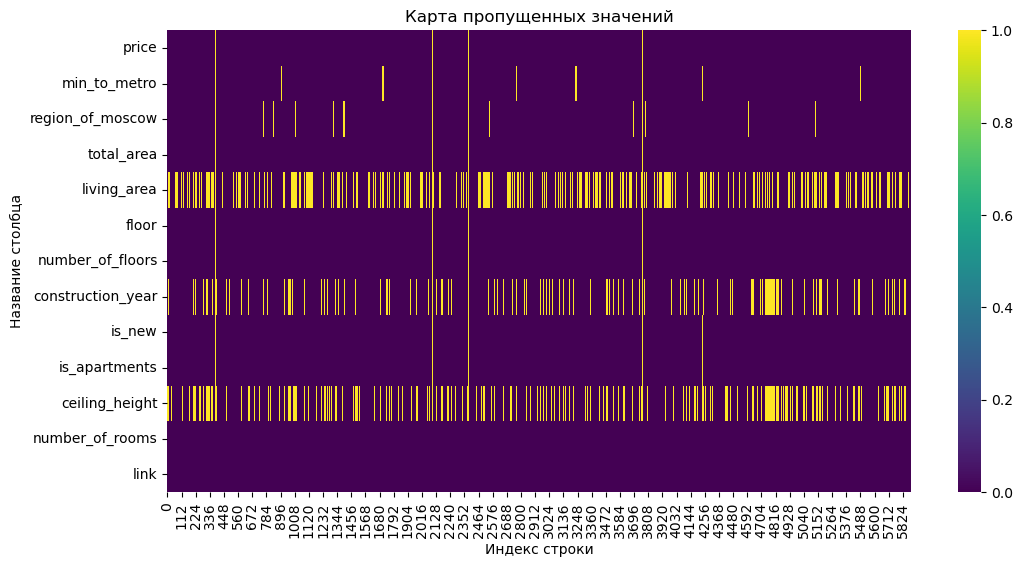

In [14]:

plt.figure(figsize=(12, 6))
sns.heatmap(df.isna().transpose(), cbar=True, cmap='viridis')
plt.title('Карта пропущенных значений')
plt.xlabel('Индекс строки')
plt.ylabel('Название столбца')
plt.show()

#### 3.2. Удаление столбцов с высоким процентом пропусков и избыточной информацией.

Анализ пропусков показал, что три столбца содержат значительную долю отсутствующих значений: `living_area` (32%), `ceiling_height` (27%), `construction_year` (16%).

Обоснование удаления:

- **`living_area` (жилая площадь)** — сильно коррелирует с общей площадью (`total_area`). Значения этого столбца не несут большой ценности в рамках данного аналитического исследования, так как не добавляют новой информации.
- **`ceiling_height` (высота потолков)** — имеет небольшую вариативность в контексте типового жилья масс-маркета. Исключением является элитное жильё и сталинки, но эти объекты **не являются целями нашего анализа**.
- **`construction_year` (год постройки)** — 16% пропусков. Столбец также удаляется, так как пропуски в нём носят системный характер, а заполнение медианой исказит распределение.
- **`min_to_metro`** - избыточны для задач данного анализа.

Решение:

1. **Удаляем столбцы** `living_area`, `min_to_metro`, `ceiling_height` и `construction_year` целиком.
2. **Удаляем строки** с пропусками в ключевых признаках — `price` (стоимость) и `total_area` (общая площадь), `region_of_moscow` (район Москвы) так как без них анализ невозможен.

In [15]:
cols_to_drop = ['living_area', 'ceiling_height', 'construction_year', 'min_to_metro']

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df.dropna(subset=['price', 'total_area', 'region_of_moscow'], inplace=True)

print(f"Итоговая размерность: {df.shape}")
print(f"Столбцы: {df.columns.tolist()}")

Итоговая размерность: (5810, 9)
Столбцы: ['price', 'region_of_moscow', 'total_area', 'floor', 'number_of_floors', 'is_new', 'is_apartments', 'number_of_rooms', 'link']


#### 3.3 Дополнительные действия со столбцом `is_apartments`:
- считаем количество пропущенных значений;
- визуализируем строки и анализируем их содержимое;
- заполняем пропущенные значения 0.0, так как эти обьекты относятся к квартирам;
- удаляем столбец - он выполнил свою роль.

In [16]:
missing_rows = df[df['is_apartments'].isna()]
print(f"Всего строк с пустыми значениями: {len(missing_rows)}")
display(missing_rows)

Всего строк с пустыми значениями: 10


,price,region_of_moscow,total_area,floor,number_of_floors,is_new,is_apartments,number_of_rooms,link
675,20000000.0,СЗАО,42.4,18.0,48.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/292001549/
1385,8900000.0,ЮВАО,32.8,6.0,9.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/295758505/
1449,18500000.0,ЮАО,37.0,8.0,8.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/295930960/
1873,29890000.0,ЦАО,45.0,26.0,35.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/297168961/
1973,9120000.0,ЮВАО,36.1,4.0,9.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/297473076/
2665,17480000.0,ЦАО,44.9,11.0,16.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/298620907/
3164,21950000.0,ЗАО,43.0,14.0,38.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/299224095/
3943,7680000.0,ЦАО,17.3,1.0,5.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/299985179/
4237,22350000.0,ЮЗАО,46.8,28.0,34.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/300190758/
5107,14250000.0,СЗАО,43.0,20.0,20.0,NaN,NaN,1.0,https://www.cian.ru/sale/flat/300615394/


In [17]:
df['is_apartments'] = df['is_apartments'].fillna(0.0)

df = df[df['is_apartments'] == 0.0].copy()

df = df.drop(columns=['is_apartments'])

#### 3.4 Оцениваем промежуточный результат:
- смотрим общее количество оставшихся пропусков;
- считаем в процентах от общего количества строк;
- визуализируем результат.
#### 3.5 Проводим дополнительную работу со столбцом `is_new`:
- выводим список строк с пропущенными значениями в столбце `is_new`;
- анализируем строки с пропусками, исходя из того, что значения `number_of_floors` (этажность дома) могут служить индикатором возраста здания:
  | Этажность дома | Типичная серия | Возраст | Классификация |
|---|---|---|---|
| 5 этажей | Хрущёвки (1960–1970-е) | 50+ лет | Вторичка |
| 9 этажей | Панельные дома (1970–1990-е) | 30–50 лет | Вторичка |
| 16 этажей | Панельные/блочные башни (1980–2000-е) | 20–40 лет | Вторичка |
| 20 этажей | Монолитные дома (2000–2010-е) | 10–20 лет | Вторичка |
| Другая этажность (25, 30, 35+) | Современные ЖК | 0–10 лет | Новостройка |

- при необходимости уточняем категорию квартиры по ссылке из столбца `link`;
- если `number_of_floors` ∈ {5, 9, 16, 20} → заполняем `0.0` (вторичка);
- остальные пропуски → заполняем `1.0` (новостройка).


,Абсолютное количество,Процент (%)
is_new,10,0.17
price,0,0.00
region_of_moscow,0,0.00
total_area,0,0.00
floor,0,0.00
number_of_floors,0,0.00
number_of_rooms,0,0.00
link,0,0.00


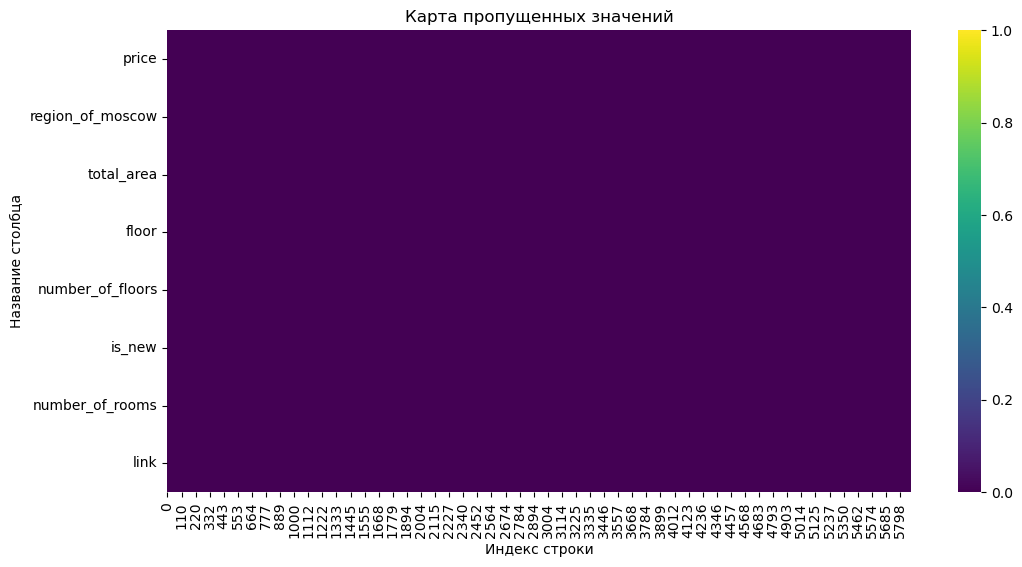

In [18]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().sum() / len(df) * 100).round(2).sort_values(ascending=False)
missing_summary = pd.concat([
    missing_count,
    missing_pct
], axis=1, keys=['Абсолютное количество', 'Процент (%)'])
display(missing_summary)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isna().transpose(), cbar=True, cmap='viridis')
plt.title('Карта пропущенных значений')
plt.xlabel('Индекс строки')
plt.ylabel('Название столбца')
plt.show()

In [19]:
missing_rows = df[df['is_new'].isna()]
print(f"Найдено строк с пропусками в 'is_new': {len(missing_rows)}")
display(missing_rows)

Найдено строк с пропусками в 'is_new': 10


,price,region_of_moscow,total_area,floor,number_of_floors,is_new,number_of_rooms,link
675,20000000.0,СЗАО,42.4,18.0,48.0,NaN,1.0,https://www.cian.ru/sale/flat/292001549/
1385,8900000.0,ЮВАО,32.8,6.0,9.0,NaN,1.0,https://www.cian.ru/sale/flat/295758505/
1449,18500000.0,ЮАО,37.0,8.0,8.0,NaN,1.0,https://www.cian.ru/sale/flat/295930960/
1873,29890000.0,ЦАО,45.0,26.0,35.0,NaN,1.0,https://www.cian.ru/sale/flat/297168961/
1973,9120000.0,ЮВАО,36.1,4.0,9.0,NaN,1.0,https://www.cian.ru/sale/flat/297473076/
2665,17480000.0,ЦАО,44.9,11.0,16.0,NaN,1.0,https://www.cian.ru/sale/flat/298620907/
3164,21950000.0,ЗАО,43.0,14.0,38.0,NaN,1.0,https://www.cian.ru/sale/flat/299224095/
3943,7680000.0,ЦАО,17.3,1.0,5.0,NaN,1.0,https://www.cian.ru/sale/flat/299985179/
4237,22350000.0,ЮЗАО,46.8,28.0,34.0,NaN,1.0,https://www.cian.ru/sale/flat/300190758/
5107,14250000.0,СЗАО,43.0,20.0,20.0,NaN,1.0,https://www.cian.ru/sale/flat/300615394/


In [20]:
floors_for_secondary = [9, 16, 5, 20]
mask_missing = df['is_new'].isna()
mask_secondary = df['number_of_floors'].isin(floors_for_secondary)
df.loc[mask_missing & mask_secondary, 'is_new'] = 0.0
df.loc[mask_missing & ~mask_secondary, 'is_new'] = 1.0

print(f"\n Пропусков в 'is_new' после заполнения: {df['is_new'].isna().sum()}")
print(f"\nРаспределение значений в 'is_new':")
print(df['is_new'].value_counts())


 Пропусков в 'is_new' после заполнения: 0

Распределение значений в 'is_new':
is_new
0.0    4243
1.0    1567
Name: count, dtype: int64


## Шаг 4. Аномалии в данных

#### 4.1 Общий обзор:
- создадим набор логических условий основаных на предметной области датасета (рынок недвижимости Москвы);
- используем словарь anomaly_checks (при необходимости можно будет добавить новые правила валидации без изменения логики кода).

In [21]:
anomaly_checks = {
    'price': [
        ('Отрицательная или нулевая цена', df['price'] <= 0),
        ('Подозрительно низкая цена (< 1 млн руб.)', df['price'] < 4_000_000),
        ('Подозрительно высокая цена (> 500 млн руб.)', df['price'] > 500_000_000)
    ],
    'region_of_moscow': [
        ('Некорректный округ Москвы', ~df['region_of_moscow'].isin([
            'ЦАО', 'САО', 'СВАО', 'ВАО', 'ЮВАО', 'ЮАО', 'ЮЗАО', 'ЗАО', 'СЗАО', 'ЗелАО'
        ]))
    ],
    'total_area': [
        ('Отрицательная или нулевая площадь', df['total_area'] <= 0),
        ('Подозрительно малая площадь (< 12 кв.м)', df['total_area'] < 12),
        ('Подозрительно большая площадь (> 300 кв.м)', df['total_area'] > 300)
    ],
    'floor': [
        ('Отрицательный или нулевой этаж', df['floor'] <= 0)
    ],
    'number_of_floors': [
        ('Отрицательная или нулевая этажность дома', df['number_of_floors'] <= 0),
        ('Этаж квартиры выше этажности дома', df['floor'] > df['number_of_floors'])
    ],
    'is_new': [
        ('Некорректный признак новостройки (не 0 и не 1)', ~df['is_new'].isin([0, 1]))
    ],
    'number_of_rooms': [
        ('Отрицательное или нулевое число комнат', df['number_of_rooms'] <= 0),
        ('Подозрительно много комнат (> 6)', df['number_of_rooms'] > 6)
    ]
}
for column, checks in anomaly_checks.items():
    for check_name, condition in checks:
        anomalies = df[condition]
        
        if len(anomalies) > 0:
            print(f"\n [{column}] {check_name}")
            print(f"Найдено: {len(anomalies)} строк\n")
            display(anomalies.head(5))


 [price] Подозрительно низкая цена (< 1 млн руб.)
Найдено: 15 строк



,price,region_of_moscow,total_area,floor,number_of_floors,is_new,number_of_rooms,link
557,3800000.0,ВАО,44.0,12.0,12.0,0.0,1.0,https://www.cian.ru/sale/flat/290644239/
889,2500000.0,СЗАО,38.0,4.0,17.0,0.0,1.0,https://www.cian.ru/sale/flat/293269136/
1365,2250000.0,ЗАО,30.6,3.0,5.0,0.0,1.0,https://www.cian.ru/sale/flat/295666829/
1447,1300000.0,ВАО,36.7,1.0,9.0,0.0,2.0,https://www.cian.ru/sale/flat/295919515/
1744,2200000.0,ЮЗАО,34.9,5.0,16.0,0.0,1.0,https://www.cian.ru/sale/flat/296830781/



 [price] Подозрительно высокая цена (> 500 млн руб.)
Найдено: 29 строк



,price,region_of_moscow,total_area,floor,number_of_floors,is_new,number_of_rooms,link
105,569100000.0,ЦАО,227.64,11.0,15.0,0.0,4.0,https://www.cian.ru/sale/flat/272126679/
108,903406350.0,ЦАО,460.10,21.0,21.0,1.0,4.0,https://www.cian.ru/sale/flat/272290927/
145,940922000.0,ЦАО,303.90,12.0,12.0,0.0,3.0,https://www.cian.ru/sale/flat/275848068/
249,599445000.0,ЦАО,363.30,21.0,21.0,1.0,4.0,https://www.cian.ru/sale/flat/283545627/
547,576973371.0,ЦАО,219.20,2.0,4.0,0.0,3.0,https://www.cian.ru/sale/flat/290411907/



 [total_area] Подозрительно большая площадь (> 300 кв.м)
Найдено: 25 строк



,price,region_of_moscow,total_area,floor,number_of_floors,is_new,number_of_rooms,link
12,280322700.0,ЦАО,340.0,6.0,7.0,0.0,4.0,https://www.cian.ru/sale/flat/239000665/
13,210000000.0,ЗАО,324.0,1.0,7.0,0.0,3.0,https://www.cian.ru/sale/flat/239000729/
66,458234336.0,ЦАО,306.7,19.0,21.0,1.0,4.0,https://www.cian.ru/sale/flat/267125571/
108,903406350.0,ЦАО,460.1,21.0,21.0,1.0,4.0,https://www.cian.ru/sale/flat/272290927/
145,940922000.0,ЦАО,303.9,12.0,12.0,0.0,3.0,https://www.cian.ru/sale/flat/275848068/


#### 4.2 Анализ аномалий: выявление подозрительных объектов ("долей").
В ходе работы над датасетом обнаруживается, что некоторые значения - это объекты, которые являются не полноценными квартирами, а долями в праве собственности. Эти значения нужно найти и удалить полностью строки. 
В таблице нет столбцов явно указывающих на эту информацию. 
Проведем следующие действия:
- Отфильтруем "доли" по условию стоимости (<5 000 000).
- Построим диаграмму рассеяния для визуального обнаружения объектов, которые могут быть долями. 
- Используем столбец `total_area` для поиска реальной квартиры с минимальной общей площадью.
- Вновь построим диаграмму рассеяния, максимум ограничим 95-м перцентилем, чтобы сфокусировать график, а так же, ограничим верхнюю границу стоимости минимальным из двух значений: либо медианой, либо стоимостью «доли» с запасом (*1,3).

Найдено строк, похожих на доли: 19 из 5810
Это составляет 0.33% от всех объявлений.


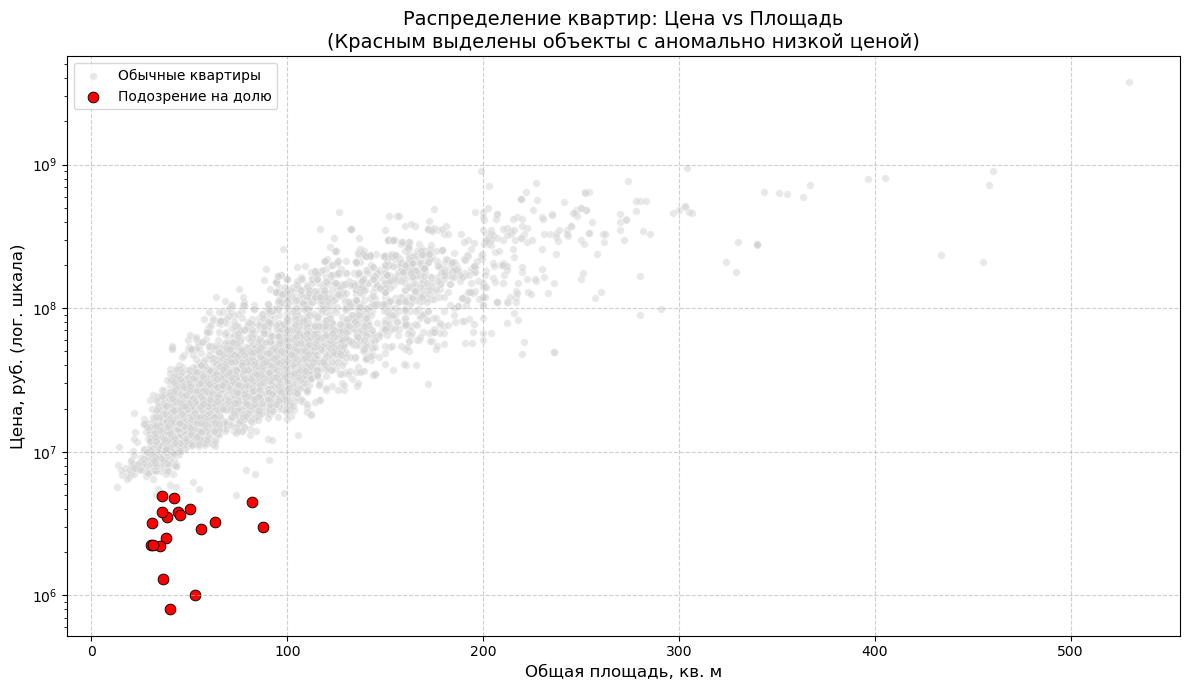

In [22]:

shares_by_price = df[(df['price'] < 5_000_000) & (df['total_area'] > 20)]

print(f"Найдено строк, похожих на доли: {len(shares_by_price)} из {len(df)}")
print(f"Это составляет {len(shares_by_price) / len(df) * 100:.2f}% от всех объявлений.")

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='total_area', 
    y='price', 
    data=df, 
    color='lightgray', 
    alpha=0.5, 
    label='Обычные квартиры',
    s=30 # размер точек
)
if not shares_by_price.empty:
    sns.scatterplot(
        x='total_area', 
        y='price', 
        data=shares_by_price, 
        color='red', 
        label='Подозрение на долю', 
        s=60, # делаем точки чуть крупнее
        edgecolor='black'
    )

plt.xscale('linear')
plt.yscale('log') 
plt.title('Распределение квартир: Цена vs Площадь\n(Красным выделены объекты с аномально низкой ценой)', fontsize=14)
plt.xlabel('Общая площадь, кв. м', fontsize=12)
plt.ylabel('Цена, руб. (лог. шкала)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

Используем столбец `total_area` для поиска реальной квартиры с минимальной общей площадью. Для подтверждения выводов проверим категорию посредством столбца `link`, который содержит ссылки на объявления.

In [23]:
df.nsmallest(5, 'total_area')

,price,region_of_moscow,total_area,floor,number_of_floors,is_new,number_of_rooms,link
3000,5690000.0,ЮВАО,13.2,1.0,12.0,0.0,1.0,https://www.cian.ru/sale/flat/299069460/
4504,8100000.0,САО,13.3,2.0,5.0,0.0,1.0,https://www.cian.ru/sale/flat/300374299/
5379,10770000.0,ЦАО,14.0,1.0,5.0,0.0,1.0,https://www.cian.ru/sale/flat/300726879/
5042,7500000.0,САО,15.3,7.0,9.0,0.0,1.0,https://www.cian.ru/sale/flat/300591126/
3467,6900000.0,САО,15.8,9.0,9.0,0.0,1.0,https://www.cian.ru/sale/flat/299501100/


Вновь построим диаграмму рассеяния, максимум ограничим 95-м перцентилем, чтобы сфокусировать график, а так же, ограничим верхнюю границу стоимости минимальным из двух значений: либо медианой, либо стоимостью «доли» с запасом (*1,3).

Медианная цена по датасету: 30,000,000 руб.
Верхняя граница графика:    7,150,000 руб.
Диапазон площади на графике: 10 – 180.0 кв.м


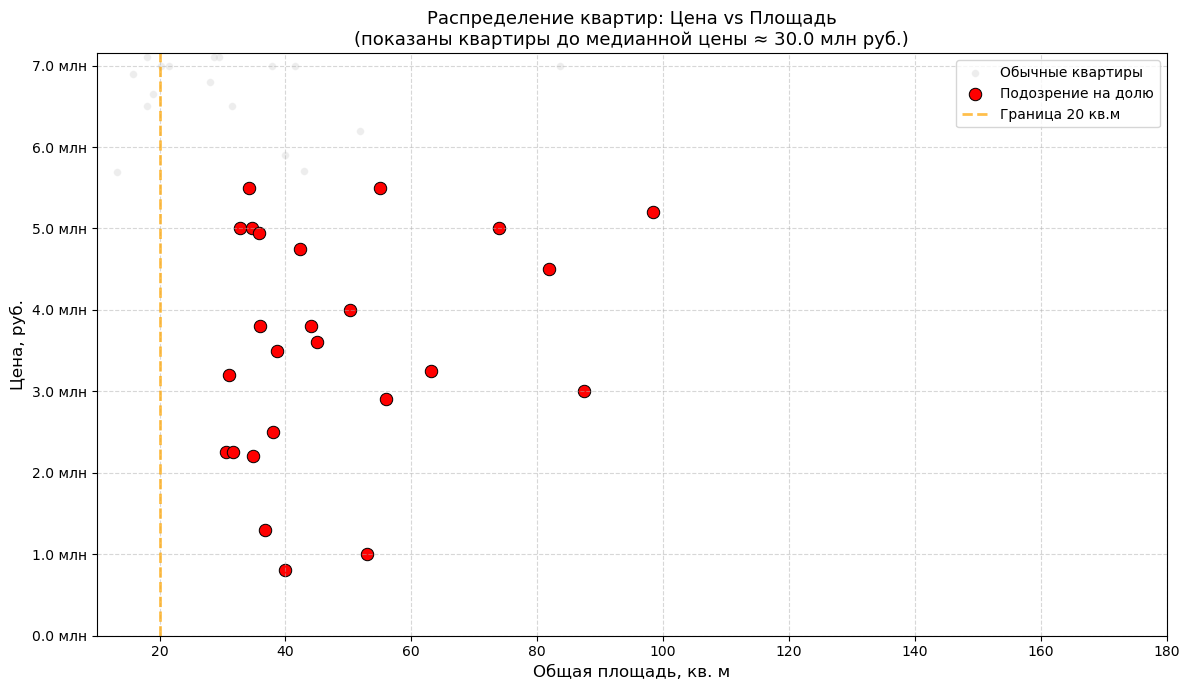

In [24]:
shares_by_price = df[(df['price'] < 5_690_000) & (df['total_area'] > 20)]

median_price = df['price'].median()
if not shares_by_price.empty:
    max_share_price = shares_by_price['price'].max()
    y_upper = min(median_price, max_share_price * 1.3)
else:
    y_upper = median_price
x_lower = 10  
x_upper = df['total_area'].quantile(0.95)  

print(f"Медианная цена по датасету: {median_price:,.0f} руб.")
print(f"Верхняя граница графика:    {y_upper:,.0f} руб.")
print(f"Диапазон площади на графике: {x_lower} – {x_upper:.1f} кв.м")

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='total_area', y='price', data=df,
    color='lightgray', alpha=0.4, label='Обычные квартиры', s=30
)
if not shares_by_price.empty:
    sns.scatterplot(
        x='total_area', y='price', data=shares_by_price,
        color='red', label='Подозрение на долю', s=80, edgecolor='black'
    )
plt.ylim(0, y_upper)
plt.xlim(x_lower, x_upper) 

plt.axvline(x=20, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Граница 20 кв.м')

plt.title(
    f'Распределение квартир: Цена vs Площадь\n'
    f'(показаны квартиры до медианной цены ≈ {median_price/1_000_000:.1f} млн руб.)',
    fontsize=13
)
plt.xlabel('Общая площадь, кв. м', fontsize=12)
plt.ylabel('Цена, руб.', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f} млн')
)
plt.tight_layout()
plt.show()

#### 4.3 Удаление «долей», проверка датасета

На основании визуального анализа диаграммы рассеяния был выявлен кластер объектов с аномально низкой ценой при площади, превышающей размер типовой микро-студии. Данные объекты классифицированы как **«доли в праве собственности»**.

**Критерии отнесения к «долям»:**
- Цена менее **5 690 000 руб.** (ниже минимальной стоимости полноценной квартиры в выборке)
- Общая площадь более **20 кв.м** (минимальная площадь квартиры в датасете составляет 13.2 кв.м)

**Важно:** Ни одна микро-студия площадью от 13.2 **не пострадала** в данном датасете.

In [25]:
before_count = len(df)
is_share = (df['price'] < 5_690_000) & (df['total_area'] > 20)
df = df[~is_share]
after_count = len(df)
removed_count = before_count - after_count

print(f"{'='*50}")
print(f"УДАЛЕНИЕ «ДОЛЕЙ» ИЗ ДАТАСЕТА")
print(f"{'='*50}")
print(f"Строк ДО удаления:   {before_count:,}")
print(f"Строк ПОСЛЕ удаления: {after_count:,}")
print(f"Удалено «долей»:   {removed_count:,}")
print(f"Процент удалений:  {removed_count/before_count*100:.1f}%")
print(f"{'='*50}")

УДАЛЕНИЕ «ДОЛЕЙ» ИЗ ДАТАСЕТА
Строк ДО удаления:   5,810
Строк ПОСЛЕ удаления: 5,785
Удалено «долей»:   25
Процент удалений:  0.4%


Убедимся, что микро-студии остались в датасете.

In [26]:
micro_studios = df[df['total_area'] <= 20]
print(f"Микро-студий (площадь <= 20 кв.м) осталось: {len(micro_studios)}")
print(f"Минимальная площадь в датасете: {df['total_area'].min():.1f} кв.м")
if len(micro_studios) > 0:
    print("\nПримеры оставшихся студий:")
    display(micro_studios[['price', 'total_area', 'number_of_rooms']].head(10))

Микро-студий (площадь <= 20 кв.м) осталось: 14
Минимальная площадь в датасете: 13.2 кв.м

Примеры оставшихся студий:


,price,total_area,number_of_rooms
597,7300000.0,20.0,1.0
1456,7100000.0,18.0,1.0
2483,7500000.0,19.7,1.0
2787,8000000.0,20.0,1.0
3000,5690000.0,13.2,1.0
3467,6900000.0,15.8,1.0
3943,7680000.0,17.3,1.0
4118,6650000.0,19.0,1.0
4504,8100000.0,13.3,1.0
4600,8450000.0,20.0,1.0


## Шаг 5. Преобразование данных
Для более глубокого анализа рынка недвижимости создаем новый признак `price_per_sqm`- **стоимость за квадратный метр**.

Новый признак price_per_sqm будет использован для:
- Построения диаграмм рассеяния (цена за метр vs район).
- Выявления выбросов (слишком дорогие/дешевые квадратные метры).
- Сравнительного анализа районов Москвы.

Примечание

Код можно упростить, так как деление на ноль или на пропуск невозможно. На предыдущих этапах очистки данных столбец `total_area` был проверен:
- Удалены строки с пропусками (NaN).
- Удалены строки с нулевыми значениями.

In [27]:
zero_count = (df['total_area'] == 0).sum()
print(f"Нулевых значений (0): {zero_count}")

Нулевых значений (0): 0


In [28]:
df['price_per_sqm'] = (df['price'] / df['total_area']).round(2)

print("Пример расчета стоимости за квадратный метр:")
print(df[['price', 'total_area', 'price_per_sqm']].head())

print("\nПроверка нового столбца на аномалии:")
print(f"Пропусков (NaN): {df['price_per_sqm'].isna().sum()}")
print(f"Нулевых значений: {(df['price_per_sqm'] == 0).sum()}")

Пример расчета стоимости за квадратный метр:
         price  total_area  price_per_sqm
0   50000000.0       162.0      308641.98
1    8700000.0        42.0      207142.86
2  108206030.0       110.0      983691.18
3  103501420.0       111.3      929931.90
4  139000000.0       149.0      932885.91

Проверка нового столбца на аномалии:
Пропусков (NaN): 0
Нулевых значений: 0


## Шаг 6. Одномерный анализ данных

#### 6.1 Проверка качества и логики этажности:
- проверяем аномалии, где этаж квартиры больше количества этажей в доме;
- ищем нулевые или отрицательные этажи.
#### 6.2 Достаточность данных для анализа:
- определим долю новостроек в выборке;
- рассчитаем дескриптивную статистику столбца `price_per_sqm`;
- визуализируем график распределения цены за квадратный метр с учетом стоимости недвижимости в Москве (экстремально высокие цены на некоторые объекты).


In [38]:
logic_errors = df[df['floor'] > df['number_of_floors']]
print(f"Объектов, где floor > number_of_floors: {len(logic_errors)}")
zero_floors = df[df['floor'] <= 0]
print(f"Объектов с floor <= 0: {len(zero_floors)}")

Объектов, где floor > number_of_floors: 0
Объектов с floor <= 0: 0


In [39]:
is_new_counts = df['is_new'].value_counts().rename({0.0: 'Вторичка', 1.0: 'Новостройка'})
print(is_new_counts)
print(f"Доля новостроек: {is_new_counts.get('Новостройка', 0) / len(df) * 100:.1f}%")

is_new
Вторичка       4218
Новостройка    1567
Name: count, dtype: int64
Доля новостроек: 27.1%


In [40]:
print(df['price_per_sqm'].describe())

count    5.785000e+03
mean     5.588005e+05
std      3.929909e+05
min      8.363202e+04
25%      3.201970e+05
50%      4.427481e+05
75%      6.148492e+05
max      7.052143e+06
Name: price_per_sqm, dtype: float64


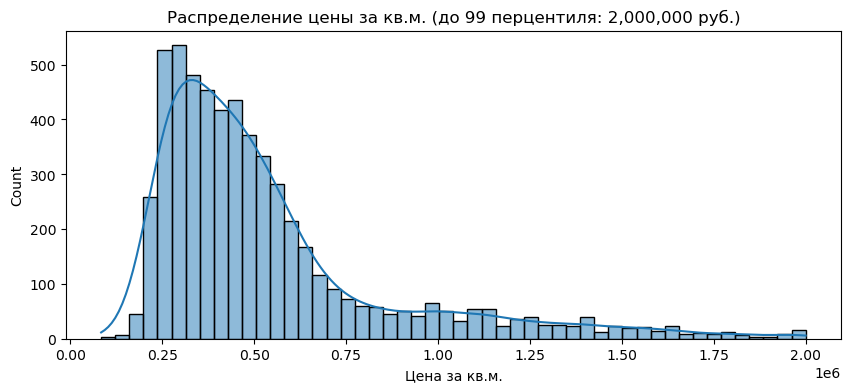

In [41]:
plt.figure(figsize=(10, 4))

q99 = df['price_per_sqm'].quantile(0.99)
sns.histplot(df[df['price_per_sqm'] <= q99]['price_per_sqm'], bins=50, kde=True)
plt.title(f'Распределение цены за кв.м. (до 99 перцентиля: {q99:,.0f} руб.)')
plt.xlabel('Цена за кв.м.')
plt.show()

## Шаг 7. Двумерный анализ данных


#### 7.1 Анализ сбалансированности и достаточности выборки

Создадим категории этажей:
  | Категория | Условие |
|---|---|
|Первый | floor == 1 |
| Последний | floor == number_of_floors |
| Средний | Все остальные значения floor |

- создадим двумерную таблицу сопряженности;
- визуализируем таблицу с помощью тепловой карты частот; 
- оценим полученный результат.

In [48]:
def get_floor_category(row):
    if row['floor'] == 1:
        return 'Первый'
    elif row['floor'] == row['number_of_floors']:
        return 'Последний'
    else:
        return 'Средний'

df['floor_category'] = df.apply(get_floor_category, axis=1)

floor_category  Первый  Последний  Средний
is_new                                    
Вторичка           228        313     3677
Новостройка         19        174     1374


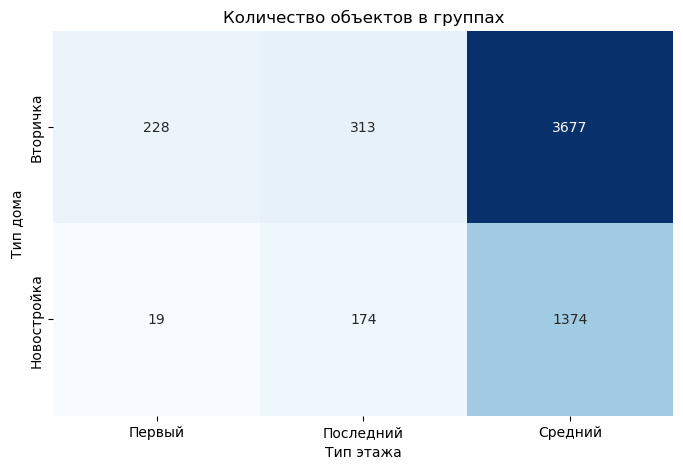

In [49]:
sample_sizes = pd.crosstab(df['is_new'].map({0.0: 'Вторичка', 1.0: 'Новостройка'}), 
                           df['floor_category'])
print(sample_sizes)

plt.figure(figsize=(8, 5))
sns.heatmap(sample_sizes, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Количество объектов в группах')
plt.ylabel('Тип дома')
plt.xlabel('Тип этажа')
plt.show()

## Важно!
Для проверки гипотезы по последним этажам данных достаточно. Но по первым этажам в новостройках в датасете всего 19 квартир. Мы знаем, что в статистике выборка менее 30 объектов считается малой. 

Однако такое количество первых этажей не случайно в контексте новостроек: очень часто в современных ЖК, как эконом, так и бизнес-класса, первые этажи делают нежилыми и отводят это место для размещения коммерческих обьектов.

Дальнейшие результаты по проверке нашей гипотезы будут учитавать этот аспект.

## Проверка гипотезы


1. Таблица медиан
   Исходя из результатов описательной статистики столбца **`price_per_sqm`** среднее значение почти на 26% выше медианы. Мы знаем, что в данных есть опеределенное количество очень дорогих квартир. Поэтому для описания "типичной" квартиры ориентиром будет выступать медиана, а не среднее.
2. Boxplot
   Визуально оценим распределение стоимости в контексте категорий этажей (Первый, Последний, Средний) во вторичке и новостройках.

Медианная цена за 1 кв.м. (руб.) в разрезе групп:
floor_category  Первый  Средний  Последний
is_new_label                              
Вторичка        275893   442097     388611
Новостройка     386793   461073     501197


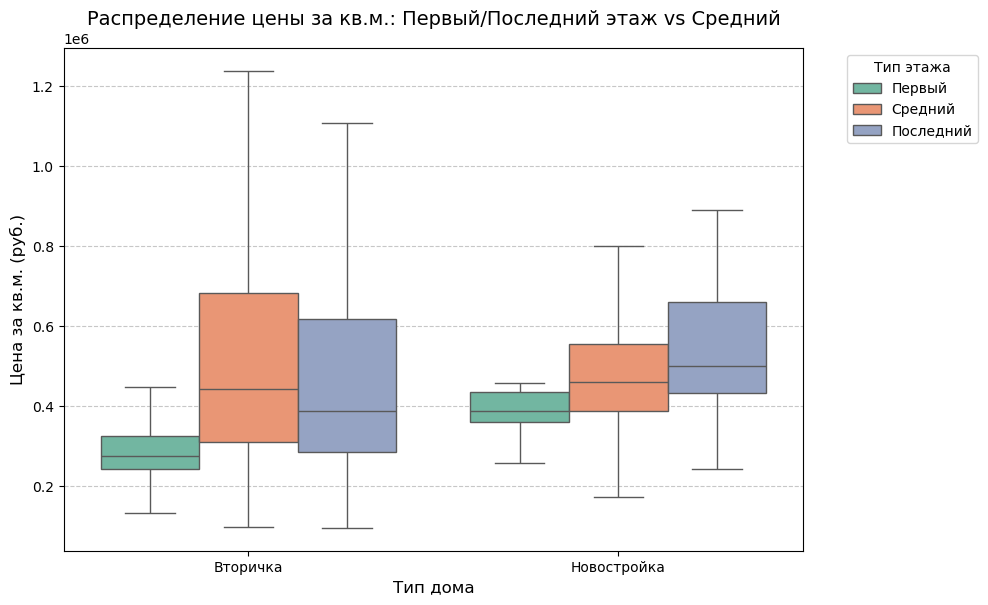

In [50]:

df['is_new_label'] = df['is_new'].map({0.0: 'Вторичка', 1.0: 'Новостройка'})
floor_order = ['Первый', 'Средний', 'Последний']

median_price_sqm = df.pivot_table(
    values='price_per_sqm', 
    index='is_new_label', 
    columns='floor_category', 
    aggfunc='median',
    observed=True
)
median_price_sqm = median_price_sqm[floor_order]
print("Медианная цена за 1 кв.м. (руб.) в разрезе групп:")
print(median_price_sqm.round(0).astype(int))

plt.figure(figsize=(10, 6))
sns.boxplot(
    x='is_new_label', 
    y='price_per_sqm', 
    hue='floor_category', 
    data=df, 
    order=['Вторичка', 'Новостройка'],
    hue_order=floor_order,
    showfliers=False, 
    palette='Set2'
)

plt.title('Распределение цены за кв.м.: Первый/Последний этаж vs Средний', fontsize=14)
plt.ylabel('Цена за кв.м. (руб.)', fontsize=12)
plt.xlabel('Тип дома', fontsize=12)
plt.legend(title='Тип этажа', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Промежуточный анализ результата
Во вторичке первый этаж торгуется со значительным дисконтом к средним этажам, тогда как в новостройках этот разрыв существенно меньше.
Для последних этажей разница ещё заметнее: во вторичке наблюдается небольшой дисконт к средним этажам, а в новостройках последние этажи, наоборот, имеют премию.
Это свидетельствует о том, что покупатели новостроек действительно меньше дисконтируют первые и последние этажи по сравнению с рынком вторичного жилья.

**Для защиты гипотезы** построим дополнительные два графика рядом. Для более полной иформации предоставим и абсолютные цифры, и относительные отклонения.

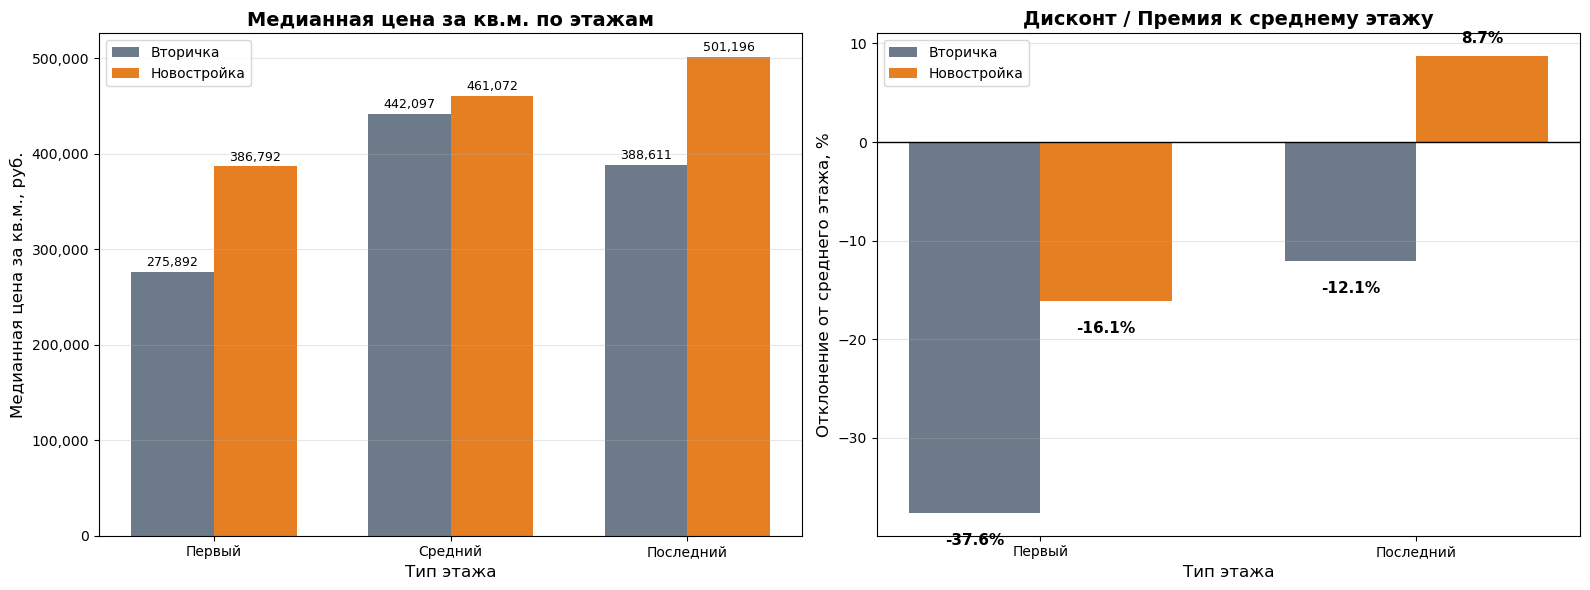


 Сводная таблица отклонений от среднего этажа:


floor_category,Первый,Средний,Последний
is_new_label,,,
Вторичка,-37.6%,0.0%,-12.1%
Новостройка,-16.1%,0.0%,8.7%


In [54]:
pivot = df.pivot_table(
    values='price_per_sqm',
    index='is_new_label',
    columns='floor_category',
    aggfunc='median'
)
pivot = pivot[['Первый', 'Средний', 'Последний']]

discount = pd.DataFrame(index=pivot.index, columns=pivot.columns, dtype=float)
for idx in pivot.index:
    base = pivot.loc[idx, 'Средний']
    for col in pivot.columns:
        discount.loc[idx, col] = (pivot.loc[idx, col] - base) / base * 100


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(pivot.columns))
width = 0.35

bars1 = ax1.bar(x - width/2, pivot.loc['Вторичка'], width, label='Вторичка', color='#6C7A89')
bars2 = ax1.bar(x + width/2, pivot.loc['Новостройка'], width, label='Новостройка', color='#E67E22')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3000,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 3000,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Тип этажа', fontsize=12)
ax1.set_ylabel('Медианная цена за кв.м., руб.', fontsize=12)
ax1.set_title('Медианная цена за кв.м. по этажам', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(pivot.columns)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{int(y):,}'))

cols_for_plot = ['Первый', 'Последний']
x2 = np.arange(len(cols_for_plot))

bars3 = ax2.bar(x2 - width/2, discount.loc['Вторичка', cols_for_plot], width, 
                label='Вторичка', color='#6C7A89')
bars4 = ax2.bar(x2 + width/2, discount.loc['Новостройка', cols_for_plot], width, 
                label='Новостройка', color='#E67E22')

for bar in bars3:
    height = bar.get_height()
    offset = 1 if height >= 0 else -2
    ax2.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{height:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', 
             fontsize=11, fontweight='bold')
for bar in bars4:
    height = bar.get_height()
    offset = 1 if height >= 0 else -2
    ax2.text(bar.get_x() + bar.get_width()/2., height + offset,
             f'{height:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', 
             fontsize=11, fontweight='bold')

ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)  # нулевая линия
ax2.set_xlabel('Тип этажа', fontsize=12)
ax2.set_ylabel('Отклонение от среднего этажа, %', fontsize=12)
ax2.set_title('Дисконт / Премия к среднему этажу', fontsize=14, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(cols_for_plot)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Сводная таблица отклонений от среднего этажа:")
display(discount.round(1).astype(str) + '%')

### **Гипотеза подтверждена**
Покупатели новостроек значительно меньше дисконтируют «проблемные» этажи. Более того, последний этаж в новостройке из «минуса» превращается в «плюс» и продается дороже средних этажей, тогда как во вторичном фонде он все еще требует скидки.
### **Выводы**

**Первые этажи**.

Во вторичном фонде первый этаж продается с огромной скидкой. В процессе эксплуатации здания накапливают дефекты и значительная их часть отражается как раз на самом нижнем этаже, особенно, если речь идет об инженерном оборудовании. Так же, к проблеме первых этажей можно отнести пониженный уровень безопасности (что подтверждает статистика проникновения и краж по городу) и повышенный уровень шума (высокая проходимость).

В новостройках дисконт к первому этажу более чем в два раза меньше (всего 16%). В современных ЖК первые этажи часто проектируются нежилыми, выводы по первым этажам новостроек носят предварительный характер. 

Однако, для последующего анализа имеет смысл обратить внимание на характеристики новых ЖК, а имеено - является ли прилегающая к ним территоррия закрытой. Потому что данный аспект существенно повышает безопасность первых этажей в новостройках.

**Последние этажи**

Во вторичке последний этаж дисконтируется на 12% — покупатели боятся протечек старой крыши, жары летом и поломок лифта.

В новостройках последний этаж продается с премией почти 9% к средней цене. Вид из окна и отсутствие соседей сверху превращают последний этаж в очень интересный вариант для проживания. Остается только надеяться на качество скоростных лифтов и хорошую гидроизоляцию крыши. Спрос рождает предложения и стоимость таких квартир подтверждает повышенный к ним интерес со стороны потенциальных покупателей.

### **Важно**
Вывод по первым этажам в новостройках является предварительным из-за малой выборки (n=19).

In [29]:
df.to_csv('moscow_flats_eda_new.csv', index=False, encoding='utf-8')


###### What happens in Vegas, stays in Vegas